In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [7]:
import pandas as pd

# 1. Veri Entegrasyonu (Yükleme)
movies_df = pd.read_csv('../csv-dosyalari/movies.csv')
ratings_df = pd.read_csv('../csv-dosyalari/ratings.csv')

print("--- VERİ YÜKLENDİ ---")
print(f"Film Sayısı: {len(movies_df)}")
print(f"Puanlama Sayısı: {len(ratings_df)}\n")

# 2. Veri Temizliği (Data Cleaning)
# Puanlamalar tablosundaki 'timestamp' (kullanıcının oyu ne zaman verdiği) bilgisi öneri motorumuz için gereksizdir. Siliyoruz.
if 'timestamp' in ratings_df.columns:
    ratings_df = ratings_df.drop('timestamp', axis=1)

# Eksik (Null/NaN) veri kontrolü
print("--- EKSİK VERİ (NULL) KONTROLÜ ---")
print("Movies Tablosundaki Boşluklar:\n", movies_df.isnull().sum())
print("\nRatings Tablosundaki Boşluklar:\n", ratings_df.isnull().sum(), "\n")

# 3. Veri Tipi Dönüşümü (Type Casting - Memory Optimization)
# Devasa verileri işlerken RAM şişmesin diye 64-bitlik sayı tiplerini 32-bit'e düşürüyoruz (Downcasting)
ratings_df['userId'] = ratings_df['userId'].astype('int32')
ratings_df['movieId'] = ratings_df['movieId'].astype('int32')
ratings_df['rating'] = ratings_df['rating'].astype('float32')

print("--- RAM OPTİMİZASYONU BAŞARILI ---")
print("Yeni Veri Tipleri:")
print(ratings_df.dtypes)

--- VERİ YÜKLENDİ ---
Film Sayısı: 9742
Puanlama Sayısı: 100836

--- EKSİK VERİ (NULL) KONTROLÜ ---
Movies Tablosundaki Boşluklar:
 movieId    0
title      0
genres     0
dtype: int64

Ratings Tablosundaki Boşluklar:
 userId     0
movieId    0
rating     0
dtype: int64 

--- RAM OPTİMİZASYONU BAŞARILI ---
Yeni Veri Tipleri:
userId       int32
movieId      int32
rating     float32
dtype: object


In [8]:
# 1. Yıl (Release Year) Özelliğini Türetme
# Regex (Düzenli İfadeler) kullanarak parantez içindeki 4 haneli sayıları yakalıyoruz.
movies_df['release_year'] = movies_df['title'].str.extract(r'\((\d{4})\)')

# 2. Tür (Genres) Formatını Temizleme
# "Action|Adventure|Sci-Fi" formatını TF-IDF algoritmasının seveceği "Action Adventure Sci-Fi" formatına çeviriyoruz.
movies_df['genres_cleaned'] = movies_df['genres'].str.replace('|', ' ')

print("--- FEATURE ENGINEERING (ÖZELLİK MÜHENDİSLİĞİ) BAŞARILI ---")
print("Türetilen Yeni Sütunlar: 'release_year' ve 'genres_cleaned'\n")

display(movies_df[['title', 'release_year', 'genres_cleaned']].head(5))

--- FEATURE ENGINEERING (ÖZELLİK MÜHENDİSLİĞİ) BAŞARILI ---
Türetilen Yeni Sütunlar: 'release_year' ve 'genres_cleaned'



,title,release_year,genres_cleaned
0,Toy Story (1995),1995,Adventure Animation Children Comedy Fantasy
1,Jumanji (1995),1995,Adventure Children Fantasy
2,Grumpier Old Men (1995),1995,Comedy Romance
3,Waiting to Exhale (1995),1995,Comedy Drama Romance
4,Father of the Bride Part II (1995),1995,Comedy


/var/folders/fm/p9jc68dn0j1fkfd41g5vgg740000gn/T/ipykernel_33948/4235420675.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tur_sayilari.values, y=tur_sayilari.index, palette='mako')


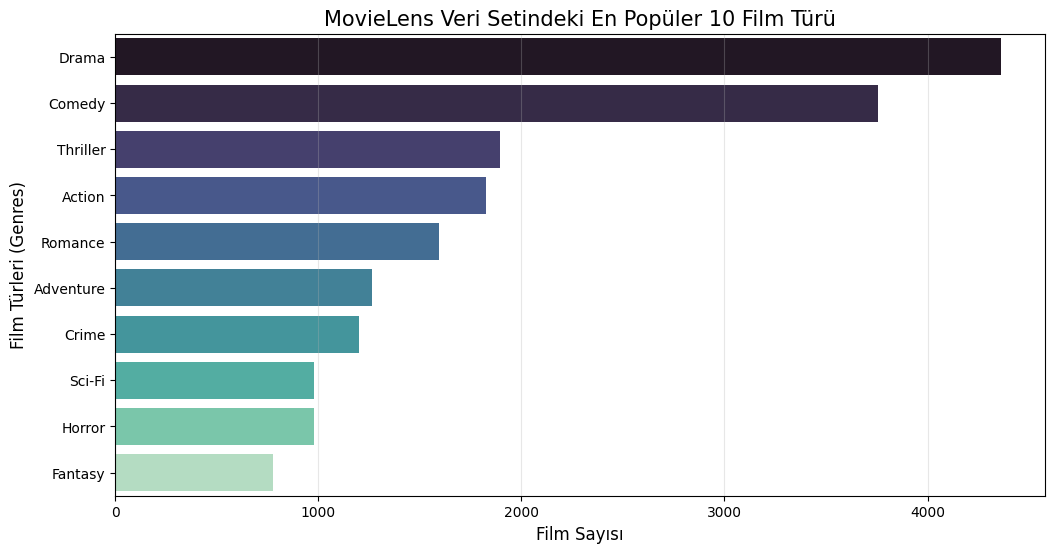

In [9]:
# 3. EDA (Keşifsel Veri Analizi): En Popüler Film Türleri Grafiği
import matplotlib.pyplot as plt
import seaborn as sns

# Temizlediğimiz türleri tek tek ayırıp sayıyoruz
tum_turler = ' '.join(movies_df['genres_cleaned']).split()
tur_sayilari = pd.Series(tum_turler).value_counts().head(10) # Sadece en popüler 10 tür

plt.figure(figsize=(12, 6))
# Seaborn kütüphanesi ile modern ve şık bir yatay çubuk (Bar) grafiği çiziyoruz
sns.barplot(x=tur_sayilari.values, y=tur_sayilari.index, palette='mako')

plt.title('MovieLens Veri Setindeki En Popüler 10 Film Türü', fontsize=15)
plt.xlabel('Film Sayısı', fontsize=12)
plt.ylabel('Film Türleri (Genres)', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Resmi tez için kaydediyoruz
plt.savefig('populer_turler.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
import sqlite3
import pandas as pd

# Veritabanınıza bağlanıyoruz
conn = sqlite3.connect('../app.db') 

# İçinde TMDb'den çekilmiş özet (description) ve yönetmen (director) olan 5 filmi getiriyoruz
zengin_veri_df = pd.read_sql_query("""
    SELECT title, director, description, genres 
    FROM movies 
    WHERE description IS NOT NULL 
    LIMIT 5
""", conn)

print("--- AŞAMA 1 (PHASE 1) KUSURSUZ TAMAMLANDI ---")
print("TMDb'den Çekilen Zenginleştirilmiş Metin (NLP) Verileri (Metadata Enrichment):\n")
display(zengin_veri_df)

conn.close()

--- AŞAMA 1 (PHASE 1) KUSURSUZ TAMAMLANDI ---
TMDb'den Çekilen Zenginleştirilmiş Metin (NLP) Verileri (Metadata Enrichment):



,title,director,description,genres
0,Inception,None,Rüyalar içinde rüya görerek bilinçaltına fikir...,Science Fiction Action
1,The Shawshank Redemption,None,Haksız yere ömür boyu hapse mahkum edilen bir ...,Drama
2,The Dark Knight,None,"Batman, Gotham şehrini terörist Joker'den koru...",Action Crime Drama
3,Cinderella,None,"Genç Ella'nın, üvey annesi ve kız kardeşlerini...",Fantasy Family Romance
4,Maleficent,None,Uyuyan Güzel masalına ikonik kötü karakter Mal...,Action Adventure Family Fantasy
